# Cars 4 You: Homework Group 21

## Introduction to the Project

Cars 4 You is an online car-resale platform that purchases used cars from private sellers.  
Currently, every car submitted on the platform needs to go through a physical inspection by a mechanic before a price offer can be made. As the company grows, this manual evaluation process has become a bottleneck, resulting in long waiting times and causing potential customers to drop out and look for alternatives.

To streamline the process, Cars 4 You has provided historical car inspection and purchase records.  
Using this dataset, our goal is to **build a machine learning model capable of predicting a car’s price based solely on attributes provided by the seller**, without requiring a mechanic to evaluate the vehicle first.

### Dataset Overview

The dataset contains several attributes that describe each car at the time of registration.  
These include characteristics such as brand, mileage, year of registration, engine size, previous owners, and more.

Below is the metadata table describing each attribute in the dataset:

<p align="center">
  <img src="images/Metadata.png" alt="Cars 4 You Dataset Metadata" width="650">
</p>

### Project Objectives

- Perform exploratory data analysis to understand the dataset and identify key variables impacting car price.
- Clean and preprocess the data (handle missing values, outliers, feature inconsistencies).
- Build and benchmark multiple regression models using a well-defined evaluation strategy.
- Optimize the best-performing model through feature engineering and hyperparameter tuning.
- Deploy the final model to generate predictions for unseen data (Kaggle competition test set).

---

**Team Members:**
- Oliver Kain, 20250401, 20250401@novaims.unl.pt  
- João Ramos, 20250413, 20250413@novaims.unl.pt  
- Gonçalo Castro, 20250415, 20250415@novaims.unl.pt  
- Mehmet Karaca, 20250344, 20250344@novaims.unl.pt

**Deliverable:** Data exploration, preprocessing, feature selection, and first benchmarks  
**Deadline:** 16.12.2025 (17:59)


# Table of Contents

<a class="anchor" id="top"></a>

** **

1. [Importing Libraries & Data](#1.-Importing-Libraries-&-Data) <br>
    
2. [Data Access & Loading](#2.-Data-Access-&-Loading) <br>

3. [Schema Overview](#3.-Schema-Overview) <br>
   
4. [Descriptive Statistics (Numeric & Categorical)](#4.-Descriptive-Statistics-(Numeric-&-Categorical)) <br>

5. [Missing Values](#5.-Missing-Values) <br>

6. [Distributions & Potential Outliers](#6.-Distributions-&-Potential-Outliers) <br>

7. [Categorical Overview](#7.-Categorical-Overview) <br>

8. [Correlation Analysis (Numerical)](#8.-Correlation-Analysis-(Numerical)) <br>

9.  [Bivariate Relations w.r.t. Target (`price`)](#9.-Bivariate-Relations-w.r.t.-Target-(`price`)) <br>

10. [Data Quality Checks](#10.-Data-Quality-Checks) <br>

11. [Duplicate Check](#11.-Duplicate-Check) <br>

12. [Key Findings for the next step](#12.-Key-Findings-for-the-next-step) <br>
   

# 00 — Data Exploration (Cars 4 You)

> **Scope:** Pure EDA. No cleaning and no modeling in this notebook.  
> The goal here is to explore the data, not transform it.

## Purpose of this Notebook

Before building any predictive model, we need to understand the dataset provided by Cars 4 You.  
This notebook focuses only on Exploratory Data Analysis (EDA). The objective is to examine the data to uncover patterns, detect anomalies, and validate assumptions.

More specifically, this notebook aims to:

- Understand the structure of the dataset: columns, data types, missing values, duplicates.
- Assess data quality and identify potential data issues: inconsistencies, incorrect values, outliers.
- Explore distributions of variables related to car characteristics, for example mileage, year, and engine size.
- Analyze relationships between features and the target variable (price), to guide feature selection later.
- Formulate initial hypotheses about what makes a car more expensive or cheaper.
- Document insights that will influence preprocessing and modeling decisions in the next phase.



# 1. Importing Libraries & Functions

In [1]:
import os, re, math, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("mode.copy_on_write", True)

# Plot Style
plt.style.use("seaborn-v0_8")

RANDOM_STATE = 42  # for reproducibility of any sampling


In [2]:
def is_safe_group(g: pd.DataFrame) -> bool:
    """
    Returns True if the rows in this group can be considered "safe duplicates".

    A group is "safe" when, for every column we compare, all non-missing values
    agree with each other. Differences caused only by missing values (NaNs) are allowed.
    """
    for col in compare_cols:
        vals = g[col].dropna()
        if vals.nunique() > 1:
            return False
    return True

# 2. Data Access & Loading

In [3]:
# Load the data paths
data_dir = "../data/"

# Load the raw data into a pandas dataframe
df = pd.read_csv(os.path.join(data_dir, "train.csv"))

# 3. Schema Overview

By creating this schema, we can understand the structure of the data and evaluate whether some data types need to be changed or not.

In [4]:
# Schema overview: data types, missing values, and unique counts for each column.
print("Shape:", df.shape)
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}))
df.info()

Shape: (75973, 14)


,column,dtype,n_unique
carID,carID,int64,75973
Brand,Brand,object,72
model,model,object,735
year,year,float64,44
price,price,int64,11048
transmission,transmission,object,40
mileage,mileage,float64,34808
fuelType,fuelType,object,34
tax,tax,float64,65
mpg,mpg,float64,217


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


* The `has_damage` has only one unique value, so it could be converted to a boolean.

* The `previousOwner` and `year` can also be converted to `int` instead of `float`.

* For the `paintQuality` we will remove it because our model predicts prices before the mechanic's inspection, this feature only exists after inspection, making it unusable in real predictions.


# 4. Descriptive Statistics (Numeric & Categorical)

From the descriptive statistics, we can see that some features contain unusual or invalid values.

In [5]:
# Here we're displaying the descriptive statistics for numerical features
display(df.describe().T)

# Here we're displaying the descriptive statistics for categorical features
display(df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
carID,75973.0,37986.000000,21931.660338,0.000000,18993.00,37986.0,56979.0,75972.000000
year,74482.0,2017.096611,2.208704,1970.000000,2016.00,2017.0,2019.0,2024.121759
price,75973.0,16881.889553,9736.926322,450.000000,10200.00,14699.0,20950.0,159999.000000
mileage,74510.0,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.000000
tax,68069.0,120.329078,65.521176,-91.121630,125.00,145.0,145.0,580.000000
mpg,68047.0,55.152666,16.497837,-43.421768,46.30,54.3,62.8,470.800000
engineSize,74457.0,1.660136,0.573462,-0.103493,1.20,1.6,2.0,6.600000
paintQuality%,74449.0,64.590667,21.021065,1.638913,47.00,65.0,82.0,125.594308
previousOwners,74423.0,1.994580,1.472981,-2.345650,1.00,2.0,3.0,6.258371
hasDamage,74425.0,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.000000


,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


* There are negative minimum values in `mileage`, `tax`, `mpg`, `engineSize`, and `previousOwner`, which are not logically possible. We will address how to handle these anomalies later.

* The maximum value for `year` is also incorrect (e.g.: 2024.12). Since the dataset only includes cars up to the year `2020`, these values must be cleaned or filtered out.

* Another observation is that the `has_damage` feature is constant (always 0), we could fill the missing values with 1 and see the behaviours or remove them.


# 5. Missing Values

The missing_total column helps us identify which features require imputation. This is
important because we want to avoid working with incomplete data and ensure the dataset
is properly normalized.

We will use different imputation methods to fill the missing values further on

In [6]:
# Here we're displaying the features sorted by number of missing values (from highest to lowest).
# This will help us identify which columns may require cleaning and/or imputation during preprocessing.
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    display(miss.to_frame("missing_total").assign(missing_percentage=lambda d: (d['missing_total']/len(df)*100).round(2)))
else:
    print("No missing values detected.")

,missing_total,missing_percentage
mpg,7926,10.43
tax,7904,10.40
previousOwners,1550,2.04
hasDamage,1548,2.04
paintQuality%,1524,2.01
transmission,1522,2.00
Brand,1521,2.00
model,1517,2.00
engineSize,1516,2.00
fuelType,1511,1.99


**Here we can see that every feature contains missing values with `mpg` and `tax` having the highest percentages. All missing values in the dataset will eventually be imputed.**

# 6. Distributions 

We created a histogram for each numeric features so we could see their distribution and find data anomalies.

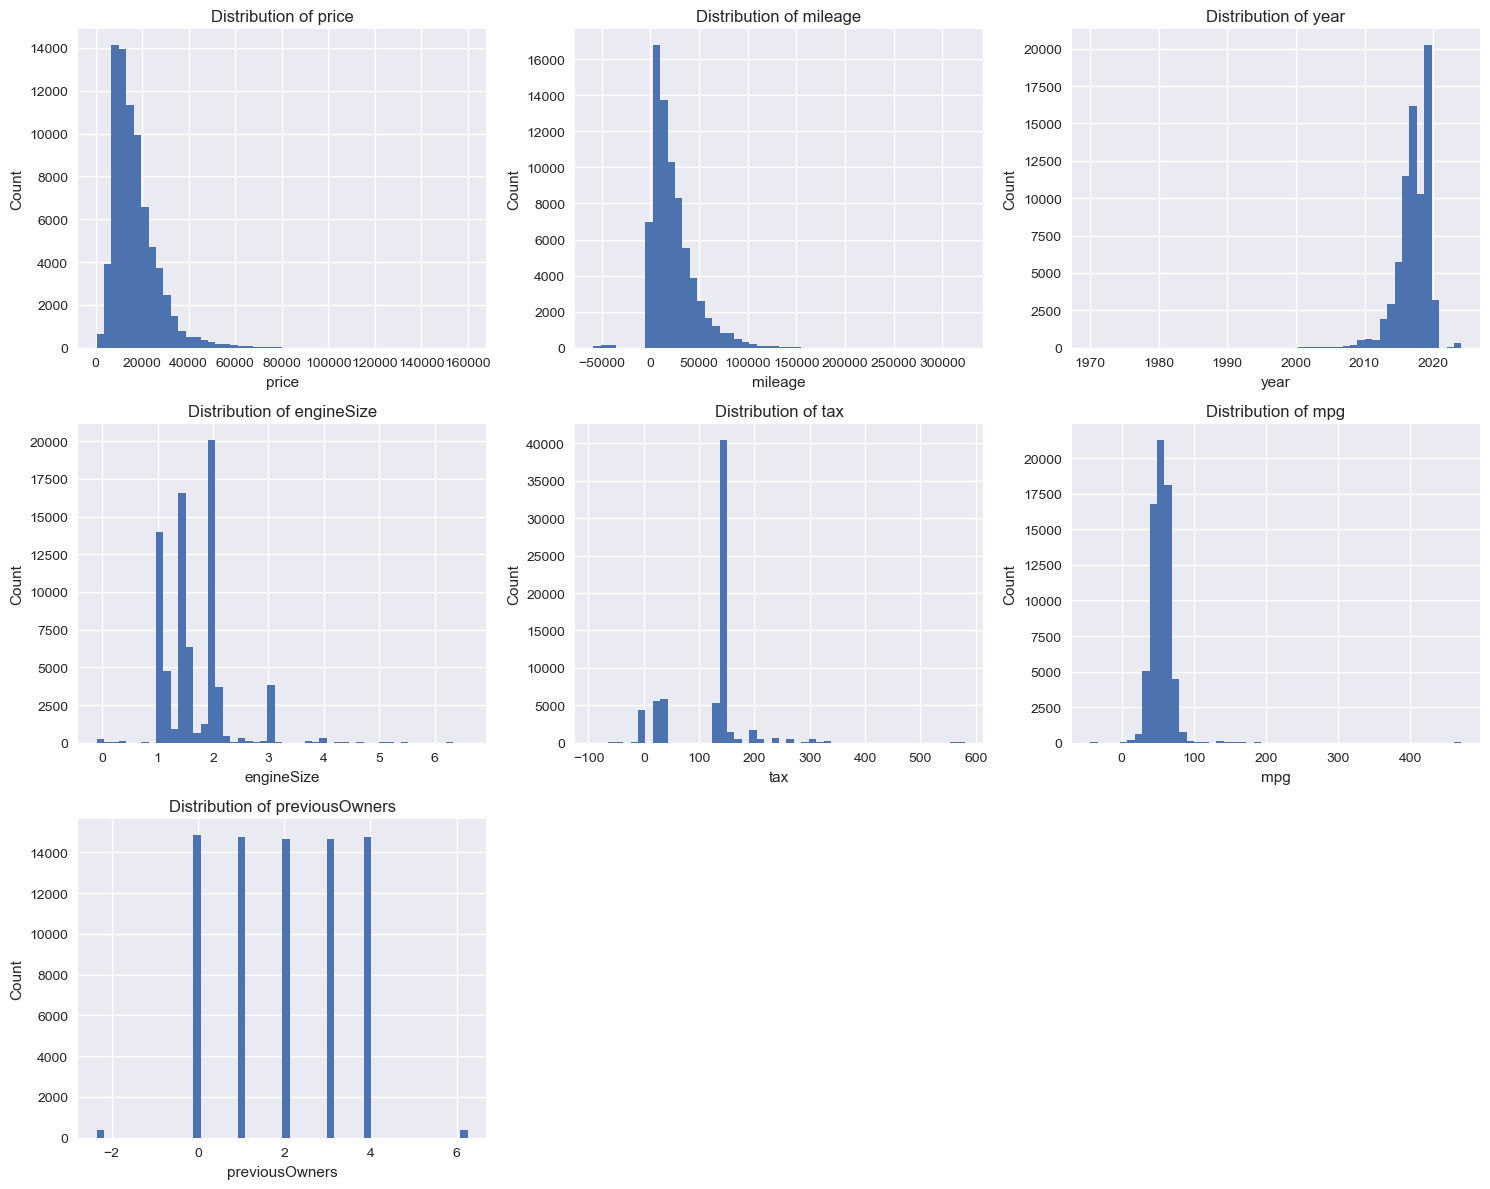

In [7]:
# Pick common numeric columns if present
num_candidates = [c for c in ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg', 'previousOwners'] if c in df.columns]

# Determine grid size (3 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to iterate easily
#Iterate over each one of the numeric collums and display a histogram where the Y is the count
# And the X is the respective value of each numeric collum
for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


From the previous histograms, we can conclude that the dataset contains the following issues:

- `Years` recorded after 2020, even though the valid upper limit is 2020 so these entries can be set to nan to impute later
- `Engine size` with a value of 0 which are not realistic. These can be treated as missing values and later imputed using the mean or median or other methods
- Negative values found in the following columns:
  - `previousOwners`
  - `tax`
  - `mpg`
  - `mileage`
- The Negative values could be converted to positive by multiplying them by -1 when appropriate or these rows can be removed if the values are invalid or unreliable, or they can be set no nan and imputed
- Several numerical features show strong right-skewness, particularly `mileage`, `mpg`, and `tax`, this affects linear models, models based on trees can handle that
- `price` is also right-skewed, a log transformation of the target value (price) could help

## Potential Outliers

Based on this analysis, we can determine the most appropriate feature scaling strategy (e.g. using a RobustScaler in the presence of many outliers, or a MinMaxScaler when outliers are limited).

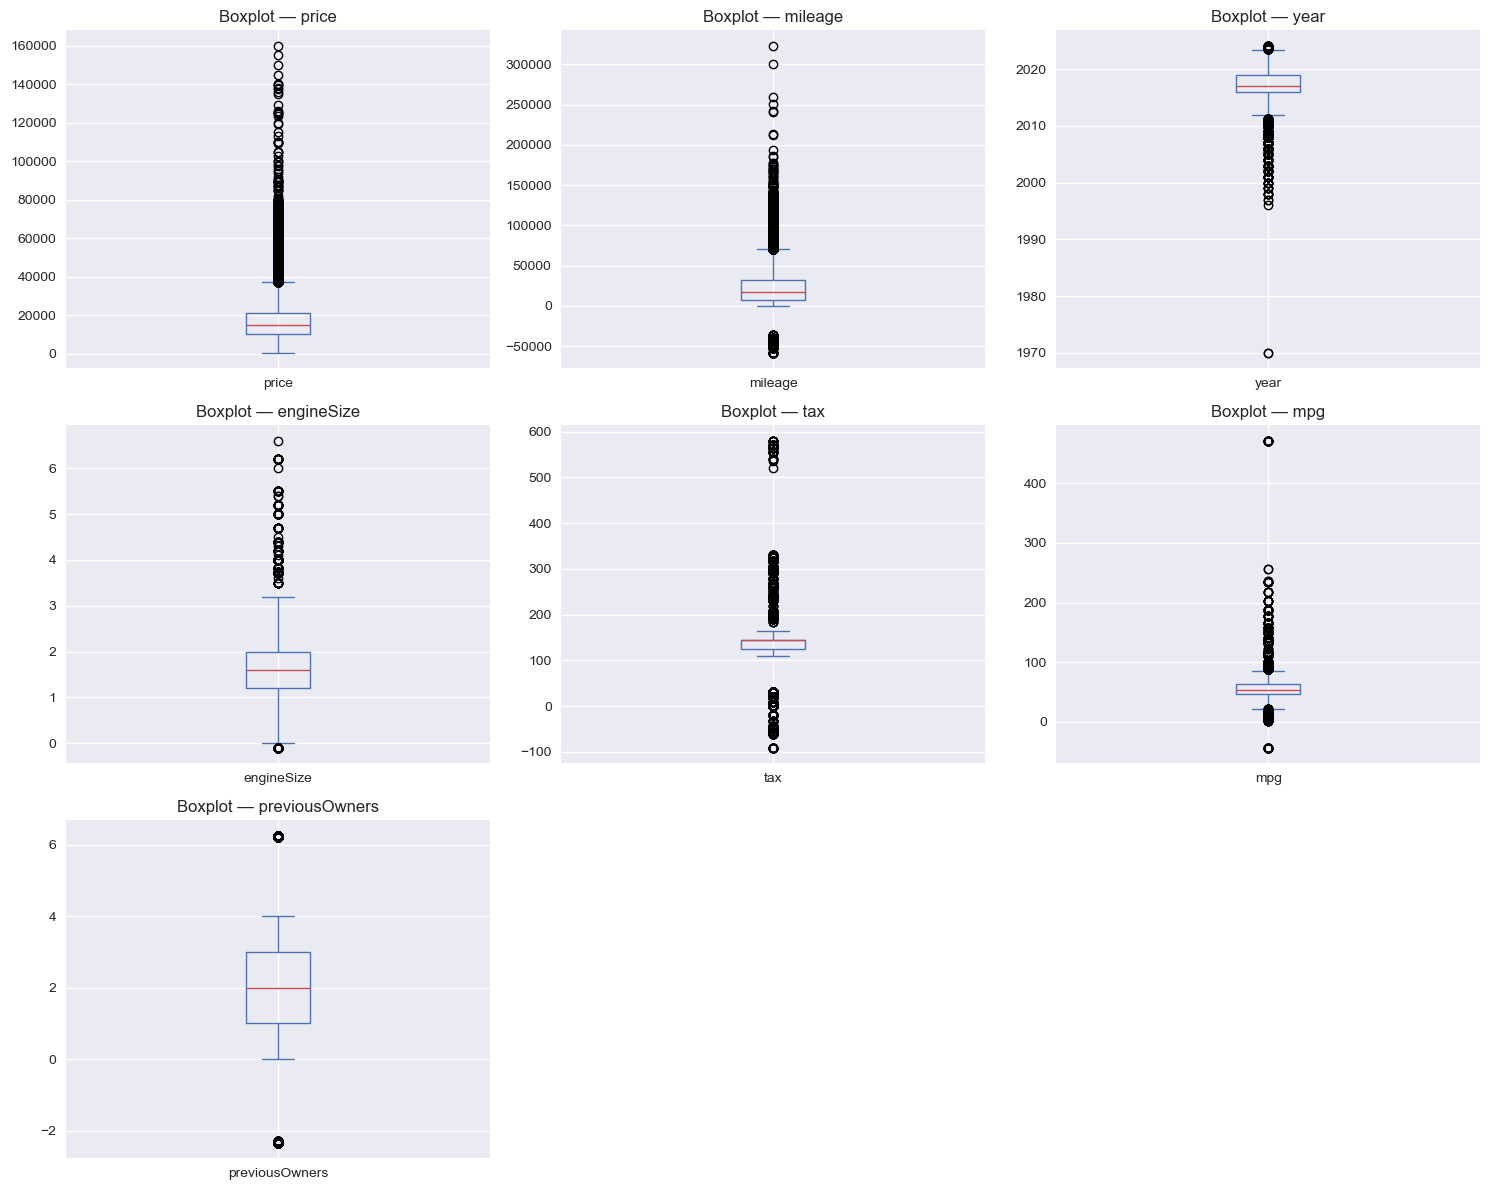

In [8]:

# Select numeric columns available
num_candidates = [c for c in ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg', 'previousOwners'] if c in df.columns]

# Set grid layout (3 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[[col]].dropna().plot(kind="box", ax=ax, title=f"Boxplot — {col}")
    ax.set_xlabel("")  # cleaner look

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


There is a high quantity of outliers in every numerical feature so we have to use the robust scaler in case we dont remove the outliers and deal with an algorithm, wo cannot deal with outliers.

# 7. Categorical Overview

We create this to understand the non-numeric data in the dataset.
It helps us inspect the categories present in each column, detect unusual or rare values, and decide whether any columns need cleaning or adjustments.

In [9]:

# Identify all categorical columns (dtype 'object') in the DataFrame
cat_cols = [c for c in df.columns if df[c].dtype=='object']

# Initialize a list to store summary DataFrames for each categorical column
summary = []

# Loop over each categorical column
for c in cat_cols:
    # Get value counts for the column, including NaN, limited to the top 15 categories
    vc = df[c].value_counts(dropna=False).head(15)
    
    # Create a DataFrame with the category names and counts, add the column name
    summary.append(pd.DataFrame({
        "category": vc.index.astype(str),  # Ensure categories are strings
        "count": vc.values
    }).assign(column=c))

# If there are any categorical columns, concatenate their summaries and display the first 50 rows of the summary DataFrame
if summary:
    summary_df = pd.concat(summary, ignore_index=True)
    display(summary_df.head(50))
else:
    # If not inform the user if no categorical columns were found
    print("No categorical columns detected.")

,category,count,column
0,Ford,14808,Brand
1,Mercedes,10754,Brand
2,VW,9780,Brand
3,Opel,8645,Brand
4,BMW,6968,Brand
5,Audi,6749,Brand
6,Toyota,4289,Brand
7,Skoda,3973,Brand
8,Hyundai,3066,Brand
9,nan,1521,Brand


* By observing the top categories for each categorical column, we can identify likely invalid or misspelled entries.

* For example, in `Brand` we see `ord` instead of `Ford` and `ercedes` instead of `Mercedes`.

* Similar issues exist in `Transmission` or `FuelType`, indicating a need for data cleaning.

* Similar issues may exist in `Model`


# 8. Correlation Analysis (Numerical)

We perform this correlation analysis to understand how the numerical features relate to each other.

The heatmap helps us visually identify strong positive or negative linear correlations, which may indicate useful predictors or redundant features that could negatively impact model performance.


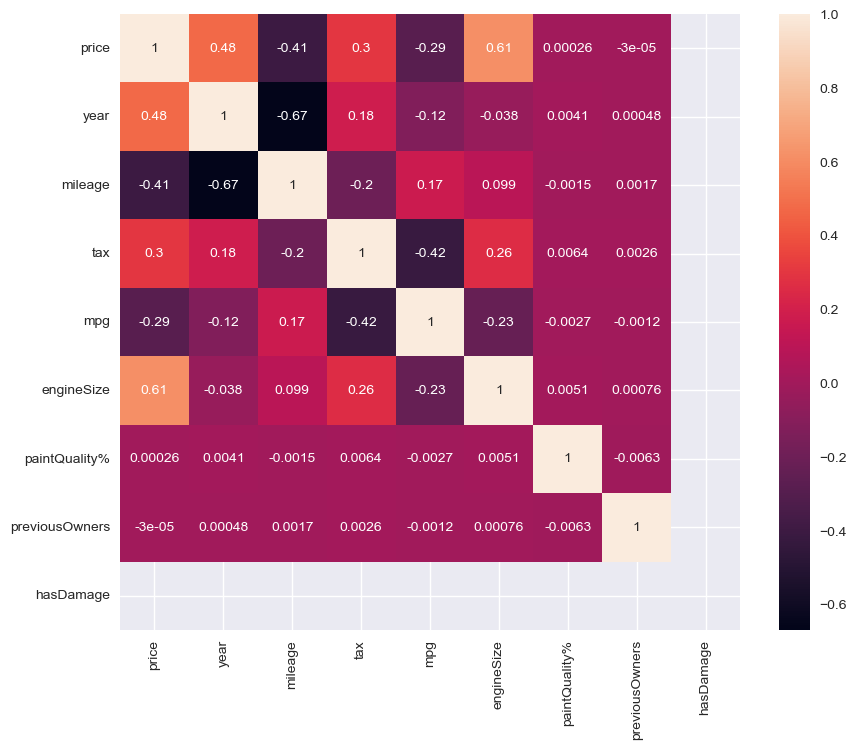

In [10]:

# Generate and display a correlation heatmap for numeric columns in the DataFrame
fig = plt.figure(figsize=(10, 8))

# Identify all numeric columns, excluding 'carID'

num_cols = df.select_dtypes(include=['number']).columns.drop('carID').tolist()

# Proceed only if there are at least two numeric columns

if len(num_cols) > 1:
# Compute the correlation matrix for numeric columns
    corr = df[num_cols].corr(numeric_only=True)

if 'price' in corr.columns:
    # Reorder columns/rows so price appears first in the correlation matrix
    cols = ['price'] + [col for col in corr.columns if col != 'price']
    corr = corr.loc[cols, cols]

    # heatmap of the correlation matrix
    ax = sns.heatmap(data=corr, annot=True)
else:
    print("Not enough numeric columns for correlation matrix.")


# display the heatmap
plt.show()


- **Strong positive correlation** between `engineSize` and `price` (**61%**).  
- **Strong negative correlation** between `year` and `mileage` (**–67%**).  
- **Moderate positive correlation** between `price` and `year` (**48%**).  
- **Moderate negative correlations** between:  
  - `price` and `mileage` (**–41%**)  
  - `tax` and `mpg` (**–42%**)

Those informations help us to find good ways to impute missing values, and in case of relations with price, to predict the target value.


# 9. Bivariate Relations w.r.t. Target (`price`)

Generate scatter plots to examine bivariate relationships between the target variable (price) and key numerical features.
With that it's easier to understand how each predictor individually influences car price.

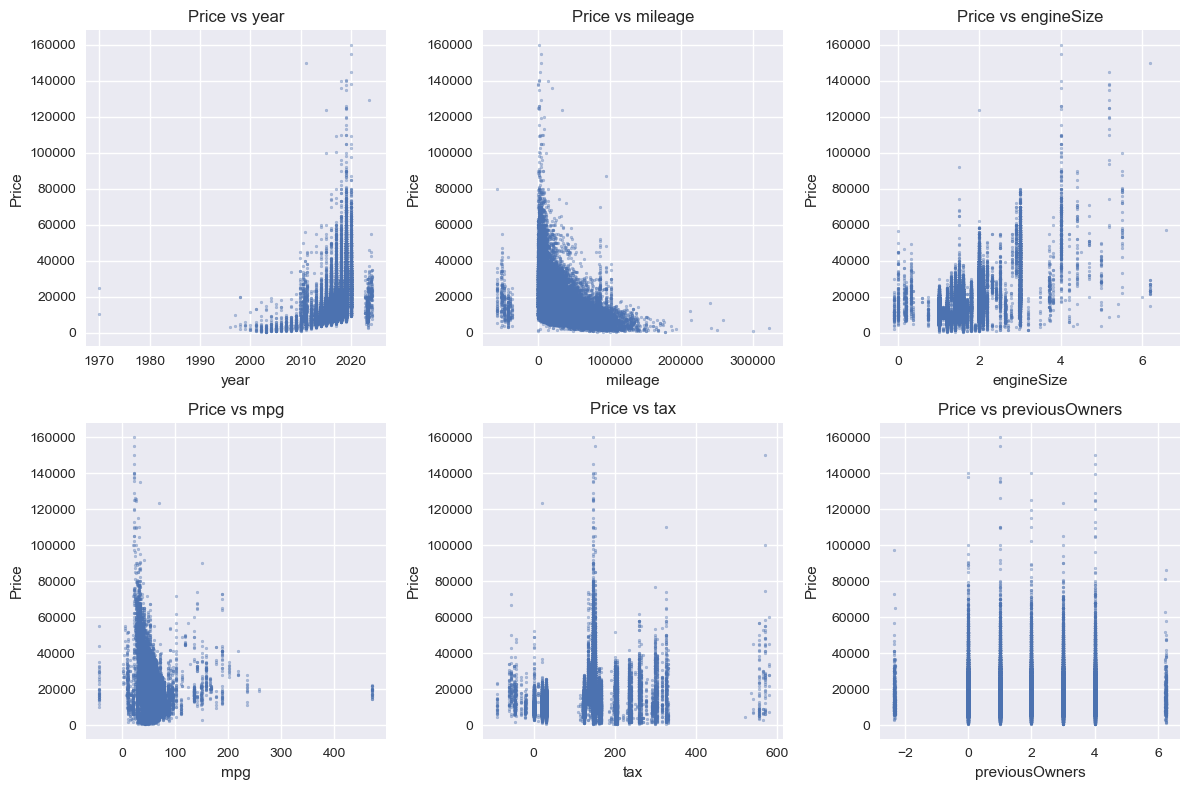

In [11]:


# Select numeric predictor columns that exist in the DataFrame
num_candidates = [c for c in ['year', 'mileage', 'engineSize', 'mpg', 'tax', 'previousOwners'] if c in df.columns]

# Define grid layout for subplots (3 columns per row)

n_cols = 3

# ceiling division to fit all plots
n_rows = (len(num_candidates) + n_cols - 1) // n_cols

# Create figure and axes for subplots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # Flatten axes array for easy iteration

# Loop through each numeric column and plot Price vs that column

for i, col in enumerate(num_candidates):
    ax = axes[i]
    # Create a scatter plot for the numeric variable against price
    ax.scatter(df[col], df['price'], s=4, alpha=0.4)
    ax.set_title(f"Price vs {col}")  # Set subplot title
    ax.set_xlabel(col)               # Label x-axis with column name
    ax.set_ylabel("Price")           # Label y-axis with 'Price'

# Hide any unused subplot axes if there are fewer plots than grid slots

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout spacing and display all scatter plots

plt.tight_layout()
plt.show()


* As expected, newer cars (closer to the year `2020`) tend to have higher prices. However, any values beyond the maximum valid `year` (2020) produce unrealistic price relationships, indicating data errors.

* The same goes to `mileage`, cars with lower mileage are generally more expensive, but the presence of negative `mileage` values is invalid, yet they still appear to have associated prices.

* The others features also contain negative values that are not logically possible, and these incorrect entries still have assigned prices. This highlights the need for proper data cleaning where we will do it afterwards.


# 10. Data Quality Checks

In [12]:
# Perform data integrity and validation checks on key columns and numeric fields
# That helps us identify invalid data, inconsistent or impossible values—such as negative numbers and incorrect ranges

# Identify cars with a 'year' later than 2020 — such records should not exist
print("Cars with year greater than 2020: " + str((df['year'] > 2020).sum()))

# Check for cars with engine sizes outside the realistic range (0.8 to )
print("Cars with unusual engine size: " + str(((df['engineSize'] > 6.2) | (df['engineSize'] < 0.8)).sum()))

print("Years before 2000: ", df.loc[df['year'] < 2000, 'year'].unique())


# Check integer-type columns ('year', 'previousOwners') for non-integer values
int_cols = ['year', 'previousOwners']
for col in int_cols:
# Identify values that are not integers
    non_int_mask = (df[col] % 1 != 0)
    count_non_int = non_int_mask.sum()
    print(f"Float numbers in {col}: {count_non_int} non-integer values")

    


Cars with year greater than 2020: 358
Cars with unusual engine size: 575
Years before 2000:  [1996. 1998. 1970. 1999. 1997.]
Float numbers in year: 2214 non-integer values
Float numbers in previousOwners: 2284 non-integer values


#### Data anomalies

Float values appear in columns where they are not appropriate, such as year and previousOwner. These entries should either be removed or rounded

There are atypical values in engineSize which require investigation and cleaning.

Also the years that are after 2020.

In the following cells we will check how to treat those anomalies.

## Check negative tax values

Compare the median of negative and positive tax values to determine if negative entries are likely sign errors and see if we find a correlation between them. We used mpg and tax, since it was the highest correlation including tax. The purpose is only to show, that negative values dont match the same patterns as the positive values. 

tax_sign
negative    -45.78061
positive    145.00000
Name: tax, dtype: float64


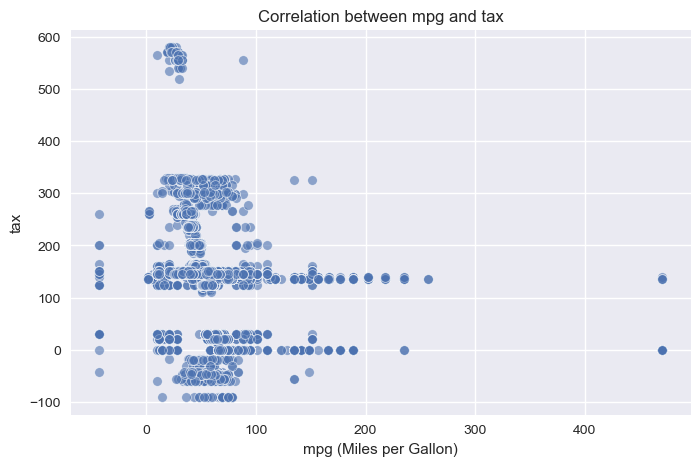

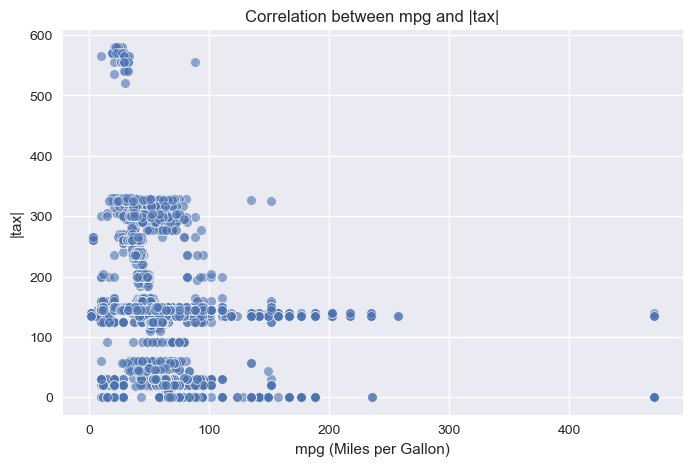

In [13]:
# classifying tax values as 'negative' or 'positive'
avg_tax_by_year = (
df.assign(tax_sign=np.where(df['tax'] < 0, 'negative', 'positive'))
.groupby(['tax_sign'])['tax']
.median()
)

# Print the median tax value for each sign group
print(avg_tax_by_year)

# Plot a scatter plot to visualize the relationship between mpg and tax
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='mpg', y='tax', alpha=0.6)
plt.title('Correlation between mpg and tax')
plt.xlabel('mpg (Miles per Gallon)')
plt.ylabel('tax')
plt.show()

# Plot a scatter plot to visualize the relationship between mpg and |tax|
df_abs = df.copy()

num_cols = df_abs.select_dtypes(include="number").columns
df_abs[num_cols] = df_abs[num_cols].abs()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_abs, x="mpg", y="tax", alpha=0.6)
plt.title("Correlation between mpg and |tax|")
plt.xlabel("mpg (Miles per Gallon)")
plt.ylabel("|tax|")
plt.show()

- The median of negative tax values (ca.-46) is far from the median of positive values (ca.145). If negatives were simple sign errors, their absolute values would be similar to the positive distribution.
- A true sign error would produce mirror symmetry (e.g. +145 and −145), which is not observed here. (see frist diagram)
- After applying `|tax|`, the negative values still do not align with the main positive-tax clusters, indicating they do not follow the same pattern. (see second diagram)

Conclusion: Negative tax values likely represent invalid entries and should be treated as missing or removed rather than converted by changing their sign.

Check for non-integer year values and compare their average mileage against integer year values. With this information we want to decided how to treat them.

In [14]:
# Display frequency of all 'year' values, including missing entries
print(df["year"].value_counts(dropna=False))

# Compute mean mileage for each distinct year value
mean_mileage = df.groupby("year")['mileage'].mean().reset_index()

# Separate years into non-integer and integer groups based on remainder check
float_years = mean_mileage[mean_mileage['year'] % 1 != 0]
int_years = mean_mileage[mean_mileage['year'] % 1 == 0]

# Display non-integer years and their corresponding mean mileage
print(float_years)

# Display integer years and their corresponding mean mileage
print(int_years)


year
2019.000000    20271
2017.000000    16146
2016.000000    11502
2018.000000    10304
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
NaN             1491
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2011.111188       15
2001.000000       15
2022.878006       12
2000.000000        6
1998.000000        5
1999.000000        5
1970.000000        2
1997.000000        2
1996.000000        1
Name: count, dtype: int64
           year       mi

- **Some non-integer years are clearly invalid given the dataset constraint (≤ 2020).**  
  Values such as `2022.x`, `2023.x`, and `2024.x` cannot be fixed by rounding, because they remain outside the allowed range and should be treated as invalid.
- **The mileage patterns suggest these entries do not behave like true years.**  
  For example, vehicles with `year = 2010.676968` have an average mileage of around **19,000 km**, while the years you could round it to are **~78,922 km (2010)** and **~69,547 km (2011)**. These non-integer values do not fit smoothly into this progression.

Conclusion: Instead of rounding, non-integer (and out-of-range) `year` values should be treated as invalid and then imputed or removed.

Compare the mean mileage of negative and positive values for each year to identify potential sign errors or data inconsistencies.

In [15]:
# Create a new column that labels each mileage value as 'negative' or 'positive' based on its sign

avg_mileage_by_year = (
df.assign(mileage_sign=np.where(df['mileage'] < 0, 'negative', 'positive'))
# Group data by year and mileage sign, then calculate the mean mileage for each group
.groupby(['year', 'mileage_sign'])['mileage']
.mean()
# Reshape the result so each sign becomes a column
.unstack()
)

# Display the resulting table comparing mean negative and positive mileage per year
print(avg_mileage_by_year)


mileage_sign      negative      positive
year                                    
1970.000000            NaN  25678.500000
1996.000000            NaN  50000.000000
1997.000000            NaN  62500.000000
1998.000000            NaN  67147.750000
1999.000000            NaN  61446.200000
2000.000000            NaN  66589.200000
2001.000000            NaN  65864.466667
2002.000000  -52618.457894  83498.181818
2003.000000            NaN  89402.894139
2004.000000  -58540.574478  93506.562500
2005.000000            NaN  92521.210736
2006.000000            NaN  87987.370968
2007.000000  -50755.210230  85368.866088
2008.000000  -42707.564215  90949.845161
2009.000000  -42707.564215  82456.742820
2009.816757            NaN  31150.891892
2010.000000  -48568.891663  81670.193966
2010.268635            NaN  24029.684211
2010.371546            NaN  18839.714286
2010.565009            NaN  23144.383813
2010.676968  -42650.453719  20625.012658
2010.746403            NaN  19030.912281
2011.000000  -47

- The magnitudes do not mirror the positive values.
  If negative mileage were only a sign mistake, the absolute values of the negative group should be close to the positive mean for the same year (rough “mirror symmetry”).  
  Example:  
  - **2002**: mean negative ≈ **-52,618** vs mean positive ≈ **83,498** → `|negative|` is far smaller than the positive mean.  
  - **2004**: mean negative ≈ **-58,541** vs mean positive ≈ **93,507** → again, not a mirror.
- The negative group is unusually consistent across many years.

Conclusion: Negative mileage values likely represent invalid entries. A safe approach is to treat them as missing/invalid (set to `NaN`) and then impute or remove, rather than multiplying by `-1`.

In [16]:
# Display frequency of all 'year' values, including missing entries
print(df["previousOwners"].value_counts(dropna=False))
avg_year_by_po = (
    df.groupby("previousOwners")["price"]
      .mean()
      .sort_index()
)

print(avg_year_by_po)
avg_year_by_po = (
    df.groupby("previousOwners")["year"]
      .mean()
      .sort_index()
)

print(avg_year_by_po)

previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
 NaN          1550
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64
previousOwners
-2.345650    17138.000000
-2.340306    12196.988095
-2.340102    14144.235294
-2.339360    25103.706897
-2.337445    15017.600000
-2.335123    22344.594595
-2.317331    16457.400000
-2.312260    22590.323529
-2.299439    10813.976744
 0.000000    16854.936824
 1.000000    16945.351227
 2.000000    16875.898525
 3.000000    16789.999590
 4.000000    16946.470501
 6.217724    13609.476190
 6.227898    10201.400000
 6.230180    24213.540541
 6.233082    10370.434783
 6.241779    14378.6

In this case its not as easy as in the other cases, but since the error is similar to the other errors we have seen so far, we should probably also set them to nan. We could also round the positive values.

## Data quality at `mpg`

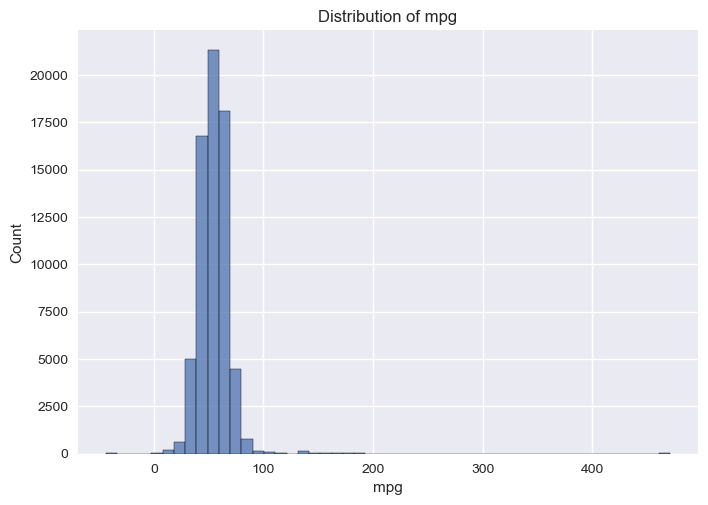

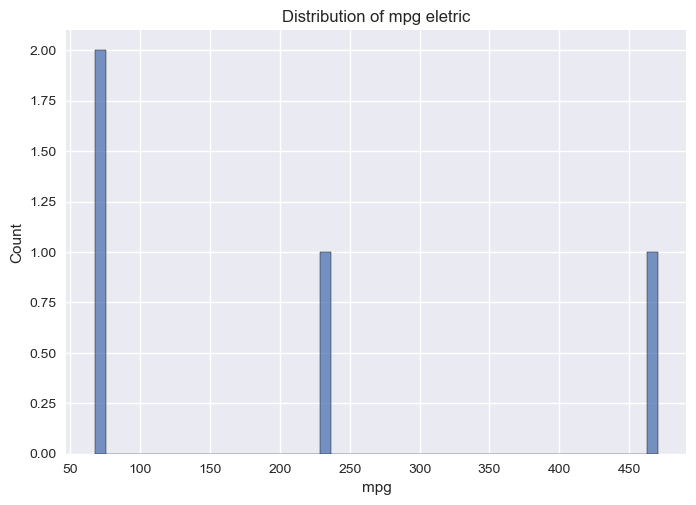

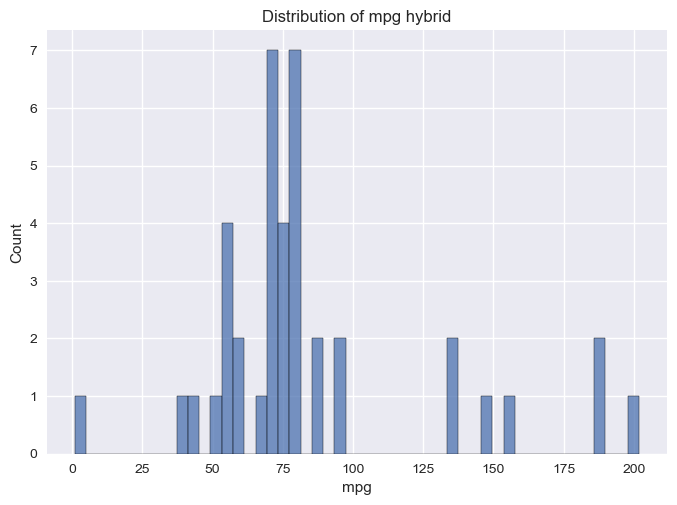

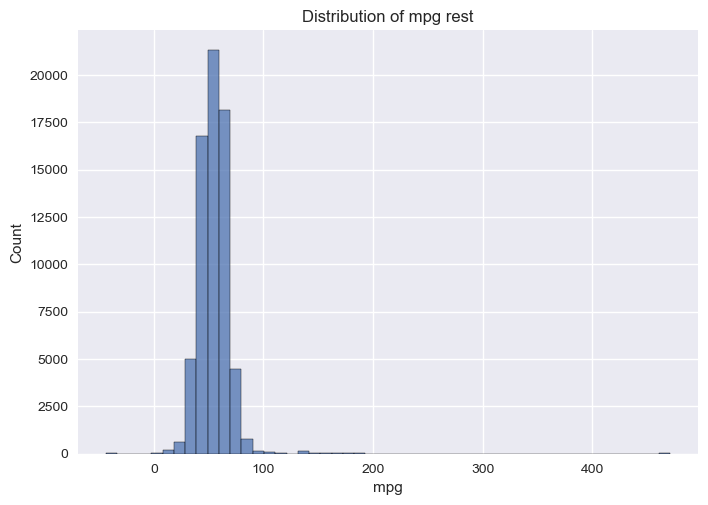

In [17]:
# now we look at the mpg histogram
# the purpose of this is to see the different 
#it doesnt exist galons on eletric cars
sns.histplot(data=df, x='mpg', bins=50)
plt.title('Distribution of mpg')
plt.show()
sns.histplot(data=df[df["fuelType"] == "Electric"], x='mpg', bins=50)
plt.title('Distribution of mpg eletric')
plt.show()
sns.histplot(data=df[df["fuelType"] == "hybrid"], x='mpg', bins=50)
plt.title('Distribution of mpg hybrid')
plt.show()
sns.histplot(data=df[(df["fuelType"] != "hybrid")& (df["fuelType"] != "Electric")], x='mpg', bins=50)
plt.title('Distribution of mpg rest')
plt.show()

- The distribution of **`mpg`** is not uniform across the dataset because it strongly depends on **`fuelType`**.  
  Therefore, potential anomalies should be checked **within each fuel type separately**, rather than using one global rule.


## Additional unusual Floats

After the unusual float values in previousOwners and year, we want to check if those errors also exist in other numerical columns.

In [18]:
print("Weird float in engineSize: ", df.loc[(df['engineSize']*10) % 1 != 0, 'engineSize'].value_counts().sum())
print(df.loc[(df['engineSize']*10) % 1 != 0, 'engineSize'].value_counts())
print("Weird float in tax: ", df.loc[df['tax'] % 1 != 0, 'tax'].value_counts().sum())
print(df.loc[df['tax'] % 1 != 0, 'tax'].value_counts())
print("Weird float in mileage: ", df.loc[df['mileage'] % 1 != 0, 'mileage'].value_counts().sum())
print(df.loc[df['mileage'] % 1 != 0, 'mileage'].value_counts())
print("Weird float in mpg: ", df.loc[(df['mpg']*10) % 1 != 0, 'mpg'].value_counts().sum())
print(df.loc[(df['mpg']*10) % 1 != 0, 'mpg'].value_counts())

Weird float in engineSize:  762
engineSize
-0.103493    84
 2.631200    80
 0.307074    65
 3.723712    63
 2.985793    52
 0.739534    52
 0.186425    52
 2.064119    51
 0.154529    39
 3.739235    38
 0.313407    35
 3.822758    27
 2.619641    25
 0.162866    24
 0.191462    21
 2.781776    19
 0.371127    18
 2.663113    17
Name: count, dtype: int64
Weird float in tax:  759
tax
 299.473504    77
-45.780610     76
 326.028233    62
 303.148891    59
-56.193202     56
 290.486785    55
-49.153541     54
-20.241079     53
-60.684095     40
 316.487189    35
 327.915778    34
-43.242082     33
-91.121630     25
-18.330743     23
 277.384254    23
 316.296306    21
-31.914945     18
 294.843409    15
Name: count, dtype: int64
Weird float in mileage:  755
mileage
 82584.134420     82
-42650.453719     78
 86705.854885     59
 85454.586292     55
-50755.210230     54
 83688.655392     49
-48190.655673     48
-42707.564215     43
-52618.457894     39
-58540.574478     39
 101153.348285   

Those are likely data errors as well, so we will set them to nan.

# 11. Duplicate Check

We check for duplicates by id and by values.

In [19]:
# Check for duplicated carId
print(f"duplicated car id: {df.duplicated('carID').sum()}")

# Columns that define a potential duplicate listing
key_cols = ["Brand", "model", "year", "price", "transmission", "mileage", "fuelType"]

# Columns that should not be used to decide whether rows are duplicates, since we checked for those already
ignore_cols = {"carID"}

# Columns to compare for consistency within a duplicate group
compare_cols = [c for c in df.columns if c not in ignore_cols]

# Group by the duplicate key and keep only groups with >1 row that are safe to treat as duplicates
grp = df.groupby(key_cols, dropna=False, sort=False)
safe_dups = grp.filter(lambda g: len(g) > 1 and is_safe_group(g)).sort_values(key_cols)



print(f"duplicated rest but not car id: {len(safe_dups)}")
safe_dups

duplicated car id: 0
duplicated rest but not car id: 40


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
63753,23465,Ford,Focus,2015.0,9450,Semi-Auto,20445.0,Petrol,NaN,44.8,1.6,38.0,NaN,0.0
64579,20215,Ford,Focus,2015.0,9450,Semi-Auto,20445.0,Petrol,NaN,NaN,1.6,38.0,0.0,0.0
20709,17201,Ford,Focus,2015.0,10000,Manual,19498.0,Diesel,0.000000,74.3,1.5,79.0,4.0,0.0
26880,24258,Ford,Focus,2015.0,10000,Manual,19498.0,Diesel,NaN,NaN,1.5,NaN,4.0,0.0
31541,29208,Ford,Focus,2016.0,9290,Manual,27583.0,Diesel,NaN,NaN,2.0,38.0,2.0,0.0
64570,23765,Ford,Focus,2016.0,9290,Manual,27583.0,Diesel,20.000000,70.6,2.0,38.0,2.0,0.0
12559,24650,Ford,Focus,2017.0,10671,Manual,36013.0,Diesel,NaN,NaN,1.5,63.0,0.0,0.0
65231,17910,Ford,Focus,2017.0,10671,Manual,36013.0,Diesel,145.000000,74.3,1.5,NaN,0.0,NaN
60018,23195,Ford,Focus,2017.0,27497,Manual,1973.0,Petrol,NaN,NaN,2.3,43.0,NaN,0.0
64615,27313,Ford,Focus,2017.0,27497,Manual,1973.0,Petrol,235.000000,36.7,2.3,NaN,4.0,0.0


We only found 40 duplicates by value, this could also be a coincidence so we should not delete them.

# 12. Key Findings for the next step

The exploratory analysis revealed several data quality issues that must be addressed before modeling. Categorical variables contain misspellings and inconsistent labels (e.g., in `Brand`, `transmission`, and `fuelType`), requiring standardization. Multiple numerical features include invalid values, such as years beyond 2020, zero engine sizes, and negative values in `mileage`, `mpg`, `tax`, and `previousOwners`, which should be treated as missing and handled through imputation or filtering. Numerical values also have unusual float values that likely represent errors.

Most numerical variables are right-skewed and contain many outliers, indicating that robust scaling is preferable if outliers are retained. The target variable `price` is also right-skewed and might benefit from a log transformation. Additionally, some features are unsuitable for modeling: `paintQuality%` should be removed, and `hasDamage` is nearly constant and provides limited information. Finally, several columns require data type corrections (e.g., `year` and `previousOwners` to integers) after cleaning.